In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import xarray as xr

alpha = 0.1 
beta = 0.1 

# **************** Fixed constants ***************
g = 9.81            # gravitational constant [m/s^2]
nu = 1.3e-6         # visosity of water [m^2/s]
rho_w = 1000        # density of water [kg/m^3]
rho_s = 2600        # density of sediment kg/m^3
# ************************************************
nf = 1 #2.5                # fractal dimension exponent
Dp = 1 * 1e-6           # reference diameter (m)
Fy = 1e-10              # yield strength (N)
beta_2 = 1.5            # winterwerp (2002)
beta_3 = 3 - nf         # winterwerp (2002)

N = 10


# D = np.zeros(N)
# D[0] = Dp 
# for i in range(1,N):
#     D[i] = D[i-1] * 2**(1/nf)
# print(D)
#     # Mass of each floc i is 2*mass i-1
    
# N = 200  # number of size classes

mass = np.zeros(N)
for i in range(N):
    mass[i] = rho_s * np.pi/6 * Dp**3 * (D[i]/Dp)**(nf)
    # mass_[i] = floc_density[i] * np.pi/6 * D[i]**3 * (D[i]/Dp)**nf 


NameError: name 'D' is not defined

In [ ]:

def flocmod_mass_redistribute(n, N):
    """
    Redistribute negative masses in NN toward positive ones,
    setting negatives to zero. converted to python from original fortran code 
    by SW on 1/22/2025 with help from chatgpt. 

    Parameters
    ----------
    n : Number of particles per floc size class 
    N : Number of particle size classes

    Returns
    -------
    n : modified (no negatives) number of particles per floc size class 
    """

    f_mass = mass

    # Temporary copy
    NNtmp = n.copy()

    # Identify negative and positive entries
    neg_mask = n < 0.0
    pos_mask = n > 0.0

    # Toal negative mass (weighted by f_mass)
    mneg = -np.sum(n[neg_mask] * mass[neg_mask])

    # Number of positive bins
    npos = np.sum(pos_mask)

    # Set negative entries to zero in temporary array
    NNtmp[neg_mask] = 0.0

    print("There is negative mass to redistribute: %2.2e" % mneg)
    if mneg > 0.0:
        if npos == 0:
            raise RuntimeError(
                "CAUTION: all floc sizes have negative mass! "
                "Simulation stopped."
            )

        total_positive = NNtmp.sum()

        # Redistribute negative mass linearly over positive classes
        for iv in range(N):
            if n[iv] > 0.0:
                n[iv] = (n[iv]  - (mneg / total_positive)* n[iv]/ f_mass[iv])
            else:
                n[iv] = 0.0

    return n 

In [46]:
def calculate_aggregation(N, D, G, n):
    g1_ = np.zeros(N)
    l1_ = np.zeros(N)
    for k in range(0, N):

        _g1_ = 0 
        for i in range(0,k+1):
            A =  G/6 * (D[i] + D[k-i])**3
            _g1_ +=  alpha * A * n[i] * n[k-i] 

        g1_[k] = _g1_

        _l1_ = 0 

        for i in range(0,N-1): 
            A = G/6 * (D[i] + D[k])**3
            _l1_ += alpha  * A * n[i] * n[k]  #* (P[i] + P[j])/P[k]

        l1_[k] = _l1_ 
    total = g1_ - l1_
    return total

[5.0e-06 2.0e-05 3.0e-05 4.0e-05 5.0e-05 6.0e-05 7.0e-05 8.0e-05 9.0e-05
 1.0e-04 1.1e-04 1.2e-04 1.3e-04 1.4e-04 1.5e-04 1.6e-04 1.7e-04 1.8e-04
 1.9e-04 2.0e-04 2.1e-04 2.2e-04 2.3e-04 2.4e-04 2.5e-04 2.6e-04 2.7e-04
 2.8e-04 2.9e-04 3.0e-04]
[ 1000.  4000.  6000.  8000. 10000.     0.     0.     0.     0.     0.
     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.
     0.     0.     0.     0.     0.     0.     0.     0.     0.     0.]
initial mass 29000.0
difference 0.0
dt_new = 10
new total 29000.0
[9.99954792e+02 3.99959011e+03 5.99905535e+03 7.99820442e+03
 9.99700840e+03 1.00613333e+00 1.57013333e+00 1.94400000e+00
 1.66666667e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
difference 0.0
d

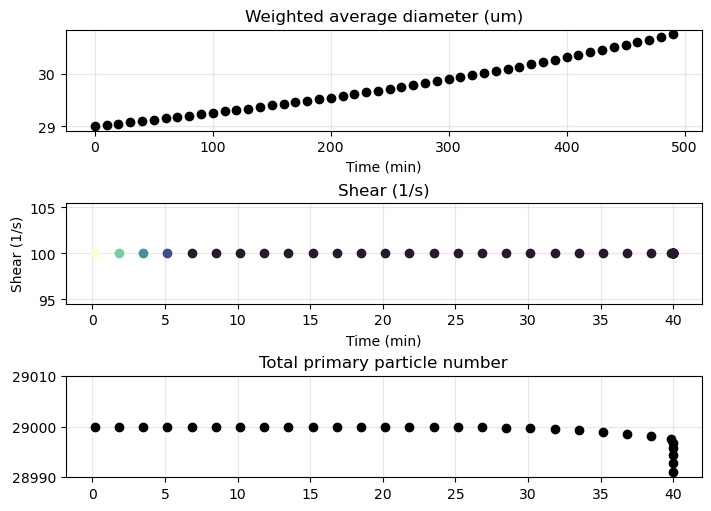

In [84]:
import cmocean as cmo 
import numpy as np 
fig , axs = plt.subplots(nrows=3, ncols=1, figsize=(7,5), constrained_layout=True)
axs= axs.flatten()

Dp = 5 * 1e-6           # reference diameter (m)
N = 30
dt = 10
alpha =1000
# D = np.geomspace(Dp, 1e-4, N)  # particle diameters from 1 micron to 1 mm
P = np.arange(1, N+1)
P[1:] = P[1:]*2
D = (Dp*P)**nf
print(D)

n = np.zeros(N) # + 1 #e8 # np.linspace(1e2, 1e4, N)  # number concentration in each size class (particles/m^3)
n[0:5] = 1e3
n = n*P
print(n)

n_particles = np.sum(n)


mass = np.zeros(N)
for i in range(N):
    mass[i] = rho_s * np.pi/6 * Dp**3 * (D[i]/Dp)**(nf)
mass_dp = mass[0]

print("initial mass", sum(n))
time = 0
for t in range(500):
    # G = 3  - np.sin(t/1000 * 2 * np.pi)   # shear rate varies between 1 and 19 1/s
    G = 100

        # agg (+)   agg(-)  shear(+)    shear(-)
    total = calculate_aggregation(N, D, G, n)
    # total[total<0] = 0
    difference = np.sum(n + (total * dt)) - n_particles
    print("difference", difference)
    threshold = 3 
    if abs(difference) < threshold:
        dt_new = dt
    else:
        count = 0 
        dt_new = dt 
        while abs(difference) > threshold:
            dt_new = dt_new/10
            difference = np.sum(n + (total * dt_new)) - n_particles
            count +=1
            if count>20:
                print("Warning: more than 10 iterations to find suitable dt_new")
                break
            # print(dt_new, difference)

    # if (n + (total * dt) )
    print("dt_new =", dt_new)
    time += dt_new
    new_total = n + (total * dt_new) 
    print("new total", np.sum(new_total))

    # change =   (g1_ -   l1_)*dt  # +  g2_    -    l2_
    n += total
    # n[n<0] = 1e-5
    
        # flocmod_mass_redistribute(n, N)
    # print(n)
    if t % 10 == 0:
        # print(np.sum(n*mass))
        print(n)
        axs[2].plot(time/60, np.sum(n), 'o', color = 'black')
        weighted_average = np.average(D*1e6, weights=n/P)
        axs[0].plot(t, weighted_average, 'o', color = 'black')
        # print(weighted_average)
        axs[1].plot(time/60, G, 'o', color=cmo.cm.deep(t/40))
        # for k, color in zip(particles2plot, colors):
        #     # axs[0].plot(t, n[k], 'o', color = color) 

        #     print(weighted_average)

axs[0].set_title("Weighted average diameter (um)")
axs[1].set_title("Shear (1/s)")
axs[1].set_ylabel("Shear (1/s)")
axs[1].set_xlabel("Time (min)")

axs[2].set_title("Total primary particle number")
axs[0].set_xlabel("Time (min)")
axs[1].set_xlabel("Time (min)")
axs[2].set_ylim(n_particles-10, n_particles+10)
for ax in axs:
    ax.grid(alpha=0.3)

In [ ]:
######################### Aggregation #########################
def A(G, i, j):
    #  Two-body collision probability function A(i,j) is a function of the 
    # shear rate G and the particle diameters D_i and D_j
    # parameters:
    #   G: shear rate (1/s)
    #   D: array of particle diameters (m)
    #   i, j: indices of the particle size classes for particles i and j
    # returns: collision probability between particles i and j (m^3/s) 
    return  G * 1/6 * (D[i] + D[j])**3

def g1(k, G, n):
    # Growth due to collisions for class k 
    # Parameters:
    #   k: index of the particle size class
    #   A : collision probability function
    #   n : number concentration array
    #   G: shear rate (1/s)
    # Returns: growth rate due to aggregation for size class k (particles/m^3/s) 
    g1_ = 0 
    for j in range(k):
        for i in range(k):
            if i + j < k:
                A = G * 1/6 * (D[i] + D[j])**3
                g1_ += 0.5 * alpha * A * n[i] * n[j] * (P[i] + P[j])/P[k]
    g1_ = g1_  # divide by 2 to avoid double counting
    return g1_


# need to fix mass balance with aggregation / loss terms here! 
def l1(k, G, n):
    # Loss due to collisions for class k
    l1_ = 0 
    for i in range(N-1): # SW was N 
        l1_ += alpha * A(G,i,k) * n[i] * n[k]  #* (P[i] + P[j])/P[k]
    return l1_

######################### Shear break-up #########################
def FDBS(k,i):
    # Break-up distribution function
    # What size classes result from a floc breaking up? Using binary assumption 
    # here: a floc breaks into two equal pieces.
    closest = mass[i] - (2*mass)   # SW adding this since no mass is exactly half of another mass
                                   # instead, we find the class w/ the closest mass to half the mass of floc k
    j1 = np.argmin(abs(closest))
    # print(mass[i], mass[k]/2)
    if k == j1 : #mass[i] == mass[k]/2:    
        FDBS_ = 2
    else: 
        FDBS_ = 0
    return FDBS_



# Calculate once since diameters don't change
D_ratio_4_B = np.zeros(N)
for i in range(N):                  # SW adding abs to avoid imaginary numbers
    D_ratio_4_B[i] = D[i] * beta * abs((D[i] - Dp)/Dp)**beta_3


def B(k, G):
    # Bi = beta * G**(beta_2) * D[i] * ((D[i] - Dp)/Dp)**(beta_3)
    Bi = D_ratio_4_B[k] * G**(beta_2)
    return Bi 

def g2(k, G):
    # Growth due to shear break-up for class k
    g2_ = 0
    if k == N:
        return g2_
    for i in range(k+1, N):
        # print(B(k, G))
        g2_ += FDBS(k,i) * B(i, G) * n[i]
    return g2_

def l2(k, G):
    # Loss due to shear break-up for class k
    l2_ = B(k, G) * n[k]
    return l2_


######################### Collision break-up #########################

def g3(k, G):
    g3_ = 0
    for i in range(N):
        for j in range(N):
            g3_ += FDBC(i,j) * A(G,i,j) * n[i] * n[j]
    return g3_

def l3(k, G):
    l3_ = 0
    for i in range(N):
        l3_ += FDBC(i,k) * A(G,i,k) * n[i] * n[k]
    return l3_


def FDBC(i,j):

    tau_c = tau_collision(i,j)
    # tau_y = tau_floc_strength(i)
    # if    strength of floc i > strength of collision 
    # and   strength of floc j < strength of collision
    #    then break-up occurs for particle j only :
    #                   F_j1 and F_j2
    #   the mass of F_j1 = 13/16 of the mass of floc j
    #   the mass of F_j2 =  3/16 of the mass of floc j 
    #   F_j1 is free (!) while F_j2 sticks to floc i
    if (tau_floc_strength(i) > tau_c) & (tau_c > tau_floc_strength(j)):
        fj1 = 13/16 * mass[j]
        fj2 =  3/16 * mass[j]
        
    elif (tau_c  > tau_floc_strength(i)) & (tau_c > tau_floc_strength(j)):
        # flocs i and j break up into (2) pieces each
        fj1 = 13/16 * mass[j]
        fj2 =  3/16 * mass[j]
        fi1 = 13/16 * mass[i]
        fi2 =  3/16 * mass[i]
        # fi2 + fj2 stick together to form a new floc

    return 

def tau_collision(i,j):
    # collision-induced stress for floc i colliding with floc j
    # Parameters:
    #       G: shear rate (1/s)
    #       D: array of particle diameters (m)
    #       i, j: indices of the particle size classes for particles i and j
    #       mass(i): mass of particle i
    #       mass(j): mass of particle j
    #       Fp: relative depth of interparticle penetration and is estimated to be 0.1  (Krone, 1963; McAnally, 1999; McAnally and Mehta, 2001)
    #  
    #  Returns: collision-induced stress (Pa)
    Fp = 0.1  
    T_c = 8 * ((G * (D[i] + D[j])/2)**2 * mass[i] * mass[j])/(np.pi * Fp * D[i]**2 * (D[i] + D[j]) * (mass[i] + mass[j]))
    return T_c

# def tau_floc_strength(i):
#     # Fy is the 
#     Fy = 1e-10 # yield strength
#     tau_y = Fy * ((floc_density[i] - rho_w)/rho_w)**(2/(3 - nf))
#     return tau_y
#  FDBC is a distribution function that looks at whether or not the collision-induced stress exceeds the strength of the particles. 

# The most sensitive empirical parameters in FLOCMOD are the 
# collisional efficiency α and the fragmentation rate β, which are often assumed to be constants.


In [47]:
# # Shear break-up 
# These terms represent the gain and loss of k-class particles
# from the fragmentation of larger flocs (iZk) induced by the
# turbulent shear stress. The probability of a k-class floc to breakup
# for a given G value is expressed by the fragmentation probability
# function Bi as proposed by (Winterwerp, 2002)

# $G_2(k) =  \sum_{i= k+1}^n FDBS_{ki} n_i $

# $L_2(k) = B_k n_k $ 

# $ B_i = \beta_i G^{\beta_2} D_i \left( \frac{D_i - D_p}{D_p} \right)^{\beta_3}

# note that $\beta$ is the fragmentation rate, as a function of floc yield strength .. 

# $ \beta_2 = 3/2 $ 

# and 

# $\beta_3 = 3 - n_f $ 

# $FDBS_{ki}$ is the distribution function of fragmented flocs for shear breakup. It's a source of large uncertainty and there's three options to pick and choose from. Simplest is 

# $ FDBS_{ij} = 2 $ if $m_j = m_i/2$  
# otherwise, $ FDBS_{ij} = 0 $

In [48]:
# # and the main floc characteristic sizes in each class i 
# # (diameter Di, mass mi and density rf,i) can be expressed via the fractal dimension nf
# # mass = rho_s * pi/6 * d50^3 * (Di/Dp)^nf 

# # rho_fi = rho + (rho_s - rho) * (Di/Dp)^(nf - 3)
# # source_aggregation = 1/2  alpha(i,j) * A(i,j) * n(i) * n(j)
# # loss_aggregation(k) = alpha(i,k) * A(i,k) * n(i) * n(k)
# # A(i,j)= 1/6 * G * (Di + Dj)^3
# # alpha represents particle cohesiveness.. set as a constnat / used for calibration
# # 
# %history

In [49]:
# import numpy as np 
# import matplotlib.pyplot as plt

# N = 100 
# diameters = np.geomspace(-5, -3, N)  # particle diameters from 1 micron to 1 mm
# D = diameters**(-3)

# plt.plot(diameters, D)
# plt.xlabel("Diameter (m)")
# ax = plt.gca()
# ax.set_yscale('log')

# https://www.dropbox.com/scl/fo/f2zogo6y1c5emdq4sbvbu/AHPyW7-LSq1TFRlJQUXDNlY?rlkey=q8a7s1u5yb6iyq6buruxfi0je&st=lizwblku
# # TS3000 Optical Backscatter Sensor